# Hospital Performance, Patient Flow & Readmission Analytics
## AICTE | IBM SkillsBuild Data Analytics with AI Academic Internship 2026 | BharatCares

**Student Name:** Rafiya Ansari  
**Project Title:** Hospital Performance, Patient Flow & Readmission Analytics  
**Short Title:** Hospital Analytics & Readmission Intelligence  
**Role:** Data Analytics & Applied AI Intern  

---

### Analytical Story & Framework
This project transforms raw multi-source healthcare administration and clinical records into actionable hospital intelligence following the structured analytical paradigm:

$$\text{RAW DATA} \longrightarrow \text{INFORMATION} \longrightarrow \text{INSIGHTS} \longrightarrow \text{RISKS / OPPORTUNITIES} \longrightarrow \text{RECOMMENDED ACTIONS}$$

For key strategic findings, the investigation applies the structured problem-solving framework:
$$\text{KPI} \longrightarrow \text{TREND} \longrightarrow \text{DRIVER} \longrightarrow \text{RISK / OPPORTUNITY} \longrightarrow \text{ACTION}$$

All analyses and interpretations adhere to rigorous epidemiological standards: observed statistical patterns are described as **associated with** outcomes rather than claiming direct clinical causality.

## 2. Business Problem & Healthcare Domain Background

Unplanned hospital readmissions within 30 days of discharge represent a multi-dimensional challenge across modern healthcare delivery systems worldwide, and particularly in India's dual healthcare architecture:
1. **Clinical Quality & Patient Safety:** Rapid readmissions frequently signal premature discharge, uncoordinated transitional care, medication mismanagement, or unaddressed secondary comorbidities.
2. **Operational Bed-Capacity Constraints:** Tertiary and secondary healthcare facilities experience bed congestion, elevated occupancy, and emergency room boarding. Preventable readmissions occupy critical bed capacity needed for acute and emergent admissions.
3. **Financial Burden & Health Equity:** In India, out-of-pocket (OOP) healthcare expenditures remain a major cause of household medical impoverishment. Even with social security schemes such as Ayushman Bharat (PM-JAY) and Employees' State Insurance (ESI), index admissions and recurrent admissions impose severe financial toxicity on vulnerable populations.

### Core Business Questions:
* What is the baseline 30-day and 7-day readmission rate across participating hospital facilities and tiers?
* How does patient flow progress from admission intake through ward placement, surgical/diagnostic procedures, length of stay (LOS), to discharge disposition?
* What are the primary clinical, demographic, and operational drivers associated with unplanned 30-day readmissions?
* Can machine learning models accurately predict high-risk patients at discharge to trigger targeted transitional care interventions without suffering from target leakage?

## 3. Project Objectives

1. **Data Integration & Audit:** Programmatically audit and join 5 relational tables (`admissions`, `billing`, `diagnoses`, `hospitals`, `patients`) ensuring the strict analytical grain of **ONE ROW = ONE HOSPITAL ADMISSION** without artificial row inflation.
2. **Data Cleaning & Preprocessing:** Address missing values (notably in insurance status), validate primary/foreign keys, investigate outliers, and standardize data types.
3. **KPI & Descriptive Analytics:** Compute benchmarks including total admission volumes, unique patients, 30-day/7-day readmission rates, average/median LOS, Charlson Comorbidity Index, procedure volumes, and total cost/subsidy distributions.
4. **Multi-Dimensional Exploratory Analytics:**
   * *Patient Analytics:* Examine age groups, gender distribution, state geography, BPL card status, and insurance coverage.
   * *Hospital Performance Analytics:* Analyze facility bed count, teaching vs. non-teaching status, and tier variations.
   * *Patient Flow & Clinical Pathway Analytics:* Trace the journey from admission mode through ICU/HDU/General wards to discharge disposition.
   * *Financial Analytics:* Quantify total expenditure, government subsidy absorption, and out-of-pocket household burden.
5. **Leakage-Free Feature Engineering & Machine Learning:**
   * Formulate predictive features strictly observable up to the discharge decision point.
   * Exclude post-discharge outcome leakage (such as `readmitted_7d` and in-hospital mortality indicators).
   * Train, evaluate, and compare Logistic Regression, Random Forest, and XGBoost classifiers using stratified holdout validation.
6. **Explainability & Actionable Strategy:** Utilize SHAP (SHapley Additive exPlanations) to identify influential model drivers, culminating in an evidence-based roadmap of clinical and administrative recommendations.

## 4. Dataset Description & Architecture

The project leverages real hospital administration and clinical data located in `data/`:
* `admissions.csv` (120,000 records, 17 columns): Core admission encounter file containing `admission_id`, `patient_id`, `hospital_id`, dates, LOS, admission/ward/discharge types, lab markers (`hba1c`, `creatinine`, `haemoglobin`, `systolic_bp`), and targets (`readmitted_30d`, `readmitted_7d`).
* `billing.csv` (120,000 records, 6 columns): Financial records with `bill_id`, `admission_id`, `total_cost_inr`, `govt_subsidy_inr`, `out_of_pocket_inr`, and `cost_category`.
* `diagnoses.csv` (271,341 records, 6 columns): Diagnostic codes per admission, with `icd10_code`, `diag_desc`, `diag_rank` (rank 1 = primary, ranks 2-4 = secondary), and `diag_category`.
* `hospitals.csv` (33 records, 6 columns): Facility metadata including `hospital_id`, `name`, `state`, `tier`, `beds`, and `teaching` status.
* `patients.csv` (86,400 records, 8 columns): Master patient demographic index containing `patient_id`, `age`, `gender`, `state`, `bpl_card`, `insurance_type`, `comorbidity_count`, and `prev_admissions`.

In [1]:
# Section 5: Imports & Environment Configuration
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Explainability
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import shap

# Styling configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Ensure figures output directory exists
os.makedirs("figures", exist_ok=True)
print("Libraries imported successfully. Environment configured.")

Libraries imported successfully. Environment configured.


In [2]:
# Section 6: Data Loading from actual project repository
data_path = "data"

df_adm_raw = pd.read_csv(os.path.join(data_path, "admissions.csv"))
df_bil_raw = pd.read_csv(os.path.join(data_path, "billing.csv"))
df_dia_raw = pd.read_csv(os.path.join(data_path, "diagnoses.csv"))
df_hosp_raw = pd.read_csv(os.path.join(data_path, "hospitals.csv"))
df_pat_raw = pd.read_csv(os.path.join(data_path, "patients.csv"))

print(f"Loaded admissions.csv: {df_adm_raw.shape[0]:,} rows, {df_adm_raw.shape[1]} columns")
print(f"Loaded billing.csv:    {df_bil_raw.shape[0]:,} rows, {df_bil_raw.shape[1]} columns")
print(f"Loaded diagnoses.csv:  {df_dia_raw.shape[0]:,} rows, {df_dia_raw.shape[1]} columns")
print(f"Loaded hospitals.csv:  {df_hosp_raw.shape[0]:,} rows, {df_hosp_raw.shape[1]} columns")
print(f"Loaded patients.csv:   {df_pat_raw.shape[0]:,} rows, {df_pat_raw.shape[1]} columns")

Loaded admissions.csv: 120,000 rows, 17 columns
Loaded billing.csv:    120,000 rows, 6 columns
Loaded diagnoses.csv:  271,341 rows, 6 columns
Loaded hospitals.csv:  33 rows, 6 columns
Loaded patients.csv:   86,400 rows, 8 columns


In [3]:
# Section 7: Comprehensive Data Audit
datasets = {
    'Admissions': df_adm_raw,
    'Billing': df_bil_raw,
    'Diagnoses': df_dia_raw,
    'Hospitals': df_hosp_raw,
    'Patients': df_pat_raw
}

audit_summary = []
for name, d in datasets.items():
    audit_summary.append({
        'Dataset': name,
        'Rows': d.shape[0],
        'Columns': d.shape[1],
        'Duplicates': d.duplicated().sum(),
        'Missing Cells': d.isnull().sum().sum(),
        'Columns with Nulls': [c for c in d.columns if d[c].isnull().any()]
    })

df_audit = pd.DataFrame(audit_summary)
print("=== COMPREHENSIVE DATASET AUDIT SUMMARY ===")
print(df_audit.to_string(index=False))

print("\nMissing values detail in Patients:")
print(df_pat_raw.isnull().sum()[df_pat_raw.isnull().sum() > 0])

=== COMPREHENSIVE DATASET AUDIT SUMMARY ===
   Dataset   Rows  Columns  Duplicates  Missing Cells Columns with Nulls
Admissions 120000       17           0              0                 []
   Billing 120000        6           0              0                 []
 Diagnoses 271341        6           0              0                 []
 Hospitals     33        6           0              0                 []
  Patients  86400        8           0          24715   [insurance_type]

Missing values detail in Patients:
insurance_type    24715
dtype: int64


In [4]:
# Section 8: Data Cleaning & Standardisation
# 1. Clean patients table: impute missing insurance_type as 'Uninsured'
df_pat = df_pat_raw.copy()
null_ins_count = df_pat['insurance_type'].isnull().sum()
df_pat['insurance_type'] = df_pat['insurance_type'].fillna('Uninsured')
df_pat = df_pat.rename(columns={'state': 'patient_state'})

# 2. Standardise hospitals table columns
df_hosp = df_hosp_raw.copy().rename(columns={
    'name': 'hospital_name',
    'state': 'hospital_state',
    'tier': 'hospital_tier',
    'beds': 'hospital_beds',
    'teaching': 'hospital_teaching'
})

# 3. Standardise billing table columns
df_bil = df_bil_raw.copy().rename(columns={
    'cost_category': 'billing_cost_category'
})

# 4. Standardise admissions dates
df_adm = df_adm_raw.copy()
df_adm['admit_date'] = pd.to_datetime(df_adm['admit_date'])
df_adm['discharge_date'] = pd.to_datetime(df_adm['discharge_date'])

print(f"Data cleaning complete.")
print(f"Handled {null_ins_count:,} missing insurance values in patients by classifying as 'Uninsured'.")
print("Confirmed zero duplicate rows across all tables.")

Data cleaning complete.
Handled 24,715 missing insurance values in patients by classifying as 'Uninsured'.
Confirmed zero duplicate rows across all tables.


In [5]:
# Section 9: Data Integration (One Row = One Admission Grain)
# In diagnoses.csv, multiple diagnoses exist per admission (ranks 1 to 4).
# To prevent row explosion and preserve the grain (1 admission = 1 row),
# we aggregate diagnoses before joining.

# A. Extract primary diagnosis (diag_rank == 1)
df_primary_diag = df_dia_raw[df_dia_raw['diag_rank'] == 1].rename(columns={
    'icd10_code': 'primary_icd10',
    'diag_desc': 'primary_diag_desc',
    'diag_category': 'primary_diag_category'
})[['admission_id', 'primary_icd10', 'primary_diag_desc', 'primary_diag_category']]

# B. Calculate total diagnoses count per admission
df_diag_count = df_dia_raw.groupby('admission_id').agg(
    total_diagnoses=('diag_id', 'count')
).reset_index()

# C. Pivot secondary diagnosis categories as presence indicator counts
df_sec_diag = df_dia_raw[df_dia_raw['diag_rank'] > 1]
df_sec_piv = df_sec_diag.pivot_table(
    index='admission_id',
    columns='diag_category',
    values='diag_id',
    aggfunc='count',
    fill_value=0
)
df_sec_piv.columns = [f"sec_diag_{c.lower()}" for c in df_sec_piv.columns]
df_sec_piv = df_sec_piv.reset_index()

# Merge diagnosis aggregations
df_dia_agg = df_primary_diag.merge(df_diag_count, on='admission_id', how='left')
df_dia_agg = df_dia_agg.merge(df_sec_piv, on='admission_id', how='left')

sec_diag_cols = [c for c in df_dia_agg.columns if c.startswith('sec_diag_')]
df_dia_agg[sec_diag_cols] = df_dia_agg[sec_diag_cols].fillna(0).astype(int)

print(f"Aggregated diagnoses table created: {df_dia_agg.shape[0]:,} rows (unique admission_id: {df_dia_agg['admission_id'].nunique():,})")

Aggregated diagnoses table created: 120,000 rows (unique admission_id: 120,000)


In [6]:
# Section 10: Final Analytical Dataset Assembly & Grain Verification
df_analytical = df_adm.merge(df_pat, on='patient_id', how='left')
df_analytical = df_analytical.merge(df_hosp, on='hospital_id', how='left')
df_analytical = df_analytical.merge(df_bil, on='admission_id', how='left')
df_analytical = df_analytical.merge(df_dia_agg, on='admission_id', how='left')

# Assertions to mathematically verify grain and data integrity
assert len(df_analytical) == 120000, "Error: Row count mismatch!"
assert df_analytical['admission_id'].nunique() == 120000, "Error: Duplicate admission IDs found!"
assert df_analytical.isnull().sum().sum() == 0, "Error: Unhandled missing values present!"

print(f"Final Analytical Dataset successfully assembled!")
print(f"Total Rows:    {df_analytical.shape[0]:,} (Exactly 1 row per hospital admission)")
print(f"Total Columns: {df_analytical.shape[1]}")
print(f"Null Values:   {df_analytical.isnull().sum().sum()}")
print(f"Memory Usage:  {df_analytical.memory_usage().sum() / (1024**2):.2f} MB")

Final Analytical Dataset successfully assembled!
Total Rows:    120,000 (Exactly 1 row per hospital admission)
Total Columns: 49
Null Values:   0
Memory Usage:  74.77 MB


                   EXECUTIVE HEALTHCARE KPI BENCHMARKS                    
                  Strategic Healthcare KPI  Calculated Benchmark
                          Total Admissions               120,000
                   Total Patients Admitted                64,873
                 Total Registered Patients                86,400
                           Total Hospitals                    33
         30-Day Readmission Rate (Overall)                11.84%
30-Day Readmission Rate (Surviving Cohort)                12.62%
          7-Day Readmission Rate (Overall)                 0.84%
 7-Day Readmission Rate (Surviving Cohort)                 0.89%
              Average Length of Stay (LOS)             6.85 days
               Median Length of Stay (LOS)              5.0 days
          Average Total Cost per Admission         INR 95,779.53
           Median Total Cost per Admission         INR 30,970.50
                Average Government Subsidy INR 47,606.17 (49.7%)
               

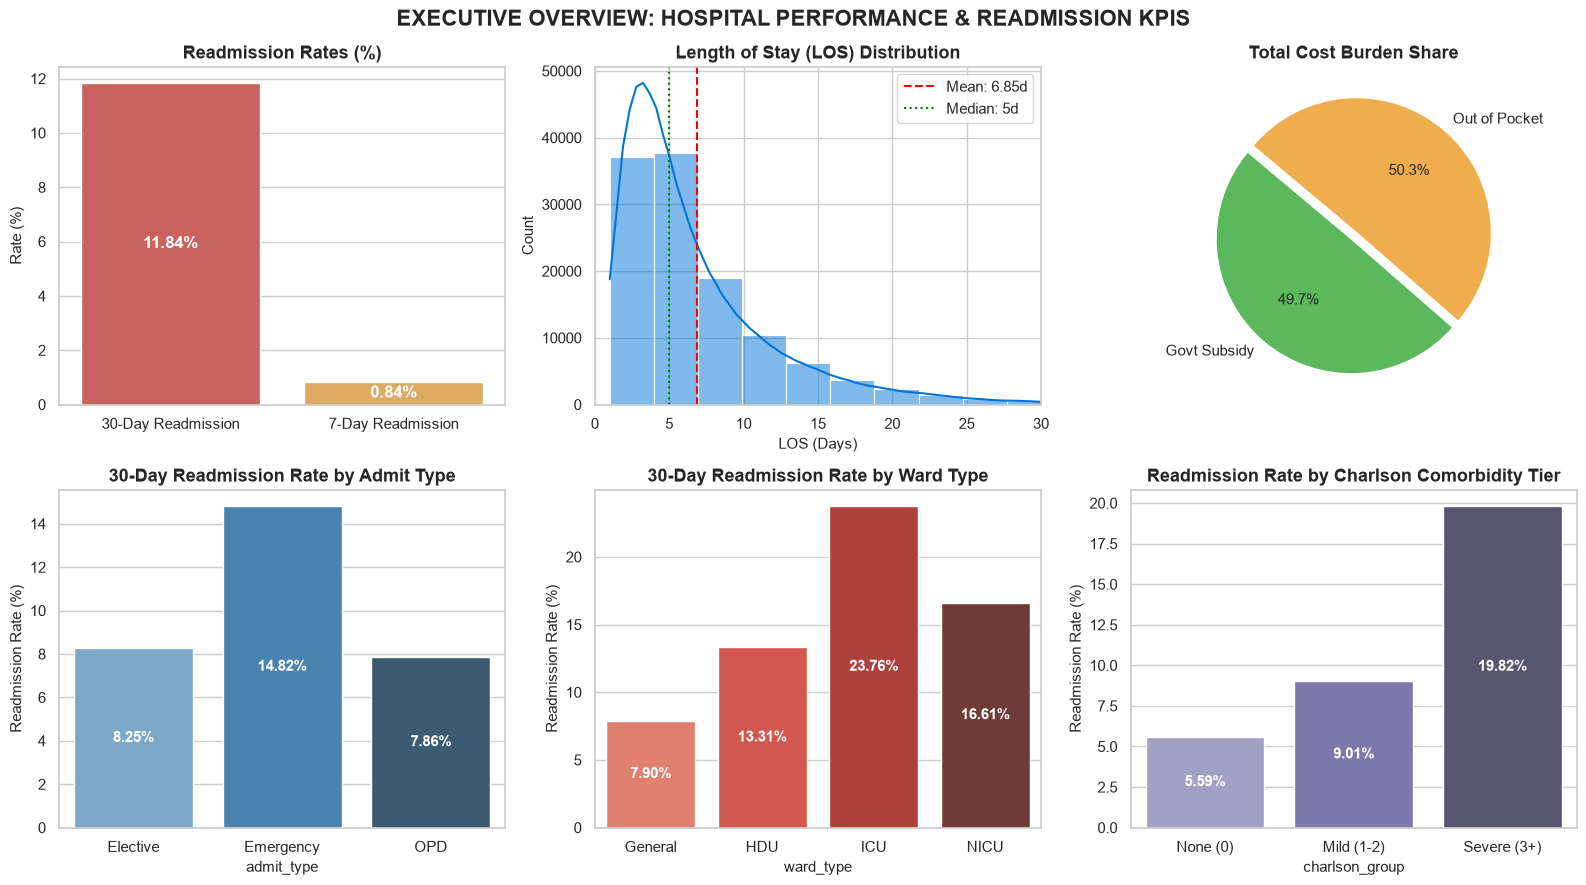

In [7]:
# Section 11: Core Hospital & Healthcare KPI Analysis
# Compute all required KPIs from actual data
total_admissions = len(df_analytical)
total_unique_patients = df_analytical['patient_id'].nunique()
total_registered_patients = len(df_pat_raw)
total_hospitals = df_analytical['hospital_id'].nunique()

rate_30d_overall = df_analytical['readmitted_30d'].mean() * 100
rate_7d_overall = df_analytical['readmitted_7d'].mean() * 100

# Non-expired (surviving) cohort analysis
df_surviving = df_analytical[df_analytical['discharge_type'] != 'Expired']
rate_30d_surviving = df_surviving['readmitted_30d'].mean() * 100
rate_7d_surviving = df_surviving['readmitted_7d'].mean() * 100

mean_los = df_analytical['los_days'].mean()
median_los = df_analytical['los_days'].median()
mean_cost = df_analytical['total_cost_inr'].mean()
median_cost = df_analytical['total_cost_inr'].median()
mean_subsidy = df_analytical['govt_subsidy_inr'].mean()
mean_oop = df_analytical['out_of_pocket_inr'].mean()
subsidy_share = (df_analytical['govt_subsidy_inr'].sum() / df_analytical['total_cost_inr'].sum()) * 100
oop_share = (df_analytical['out_of_pocket_inr'].sum() / df_analytical['total_cost_inr'].sum()) * 100
mean_procedures = df_analytical['num_procedures'].mean()
mean_charlson = df_analytical['charlson_index'].mean()
mean_age = df_analytical['age'].mean()

kpi_data = [
    ("Total Admissions", f"{total_admissions:,}"),
    ("Total Patients Admitted", f"{total_unique_patients:,}"),
    ("Total Registered Patients", f"{total_registered_patients:,}"),
    ("Total Hospitals", f"{total_hospitals}"),
    ("30-Day Readmission Rate (Overall)", f"{rate_30d_overall:.2f}%"),
    ("30-Day Readmission Rate (Surviving Cohort)", f"{rate_30d_surviving:.2f}%"),
    ("7-Day Readmission Rate (Overall)", f"{rate_7d_overall:.2f}%"),
    ("7-Day Readmission Rate (Surviving Cohort)", f"{rate_7d_surviving:.2f}%"),
    ("Average Length of Stay (LOS)", f"{mean_los:.2f} days"),
    ("Median Length of Stay (LOS)", f"{median_los:.1f} days"),
    ("Average Total Cost per Admission", f"INR {mean_cost:,.2f}"),
    ("Median Total Cost per Admission", f"INR {median_cost:,.2f}"),
    ("Average Government Subsidy", f"INR {mean_subsidy:,.2f} ({subsidy_share:.1f}%)"),
    ("Average Out-of-Pocket Cost", f"INR {mean_oop:,.2f} ({oop_share:.1f}%)"),
    ("Average Procedures per Admission", f"{mean_procedures:.2f}"),
    ("Average Charlson Comorbidity Index", f"{mean_charlson:.2f}"),
    ("Average Patient Age", f"{mean_age:.1f} years")
]

kpi_table = pd.DataFrame(kpi_data, columns=["Strategic Healthcare KPI", "Calculated Benchmark"])
print("==========================================================================")
print("                   EXECUTIVE HEALTHCARE KPI BENCHMARKS                    ")
print("==========================================================================")
print(kpi_table.to_string(index=False))

# Visualization: KPI Executive Dashboard
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Readmission Rates
sns.barplot(ax=axes[0, 0], x=['30-Day Readmission', '7-Day Readmission'],
            y=[rate_30d_overall, rate_7d_overall], color='#d9534f')
axes[0, 0].set_title("Readmission Rates (%)", fontweight='bold')
axes[0, 0].set_ylabel("Rate (%)")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# 2. LOS Distribution
sns.histplot(ax=axes[0, 1], data=df_analytical['los_days'], bins=30, kde=True, color='#0275d8')
axes[0, 1].axvline(mean_los, color='red', linestyle='--', label=f"Mean: {mean_los:.2f}d")
axes[0, 1].axvline(median_los, color='green', linestyle=':', label=f"Median: {median_los:.0f}d")
axes[0, 1].set_title("Length of Stay (LOS) Distribution", fontweight='bold')
axes[0, 1].set_xlabel("LOS (Days)")
axes[0, 1].set_xlim(0, 30)
axes[0, 1].legend()

# 3. Cost Share: Subsidy vs OOP
axes[0, 2].pie([mean_subsidy, mean_oop], labels=['Govt Subsidy', 'Out of Pocket'], autopct='%1.1f%%',
               startangle=140, colors=['#5cb85c', '#f0ad4e'], explode=(0.03, 0.03))
axes[0, 2].set_title("Total Cost Burden Share", fontweight='bold')

# 4. Readmission by Admission Type
adm_type_readm = df_analytical.groupby('admit_type')['readmitted_30d'].mean() * 100
sns.barplot(ax=axes[1, 0], x=adm_type_readm.index, y=adm_type_readm.values, color='#0275d8')
axes[1, 0].set_title("30-Day Readmission Rate by Admit Type", fontweight='bold')
axes[1, 0].set_ylabel("Readmission Rate (%)")
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                        ha='center', va='center', color='white', fontweight='bold')

# 5. Readmission by Ward Type
ward_readm = df_analytical.groupby('ward_type')['readmitted_30d'].mean() * 100
sns.barplot(ax=axes[1, 1], x=ward_readm.index, y=ward_readm.values, color='#d9534f')
axes[1, 1].set_title("30-Day Readmission Rate by Ward Type", fontweight='bold')
axes[1, 1].set_ylabel("Readmission Rate (%)")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                        ha='center', va='center', color='white', fontweight='bold')

# 6. Readmission by Charlson Index Group
df_analytical['charlson_group'] = pd.cut(df_analytical['charlson_index'], bins=[-1, 0, 2, 10], labels=['None (0)', 'Mild (1-2)', 'Severe (3+)'])
charlson_readm = df_analytical.groupby('charlson_group', observed=False)['readmitted_30d'].mean() * 100
sns.barplot(ax=axes[1, 2], x=charlson_readm.index, y=charlson_readm.values, color='#6f42c1')
axes[1, 2].set_title("Readmission Rate by Charlson Comorbidity Tier", fontweight='bold')
axes[1, 2].set_ylabel("Readmission Rate (%)")
for p in axes[1, 2].patches:
    axes[1, 2].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                        ha='center', va='center', color='white', fontweight='bold')

plt.suptitle("EXECUTIVE OVERVIEW: HOSPITAL PERFORMANCE & READMISSION KPIS", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("figures/01_kpi_dashboard_summary.png", dpi=300)
plt.show()

=== PATIENT DEMOGRAPHICS & READMISSION ASSOCIATIONS ===

Age Group Breakdown:
                     Admissions Readmission_Rate  Mean_LOS      Mean_Cost
age_group                                                                
Pediatric (0-18)          16361            6.19%  6.952509   77651.353951
Young Adult (19-45)       31645            6.96%  6.088482   76844.032201
Middle Aged (46-65)       46781           12.51%  6.806802   99632.356491
Elderly (66+)             25213           20.40%  7.832309  124160.525443

Insurance Coverage Breakdown:
                Admissions Readmission_Rate      Mean_OOP  Mean_Subsidy
insurance_type                                                         
Ayushman             36264           13.92%  32537.806530  63730.866893
ESI                  19841           12.15%  24192.468374  72257.954589
Private              29908            9.31%  31862.245720  65799.582052
Uninsured            33987           11.67%  93209.575367      0.000000


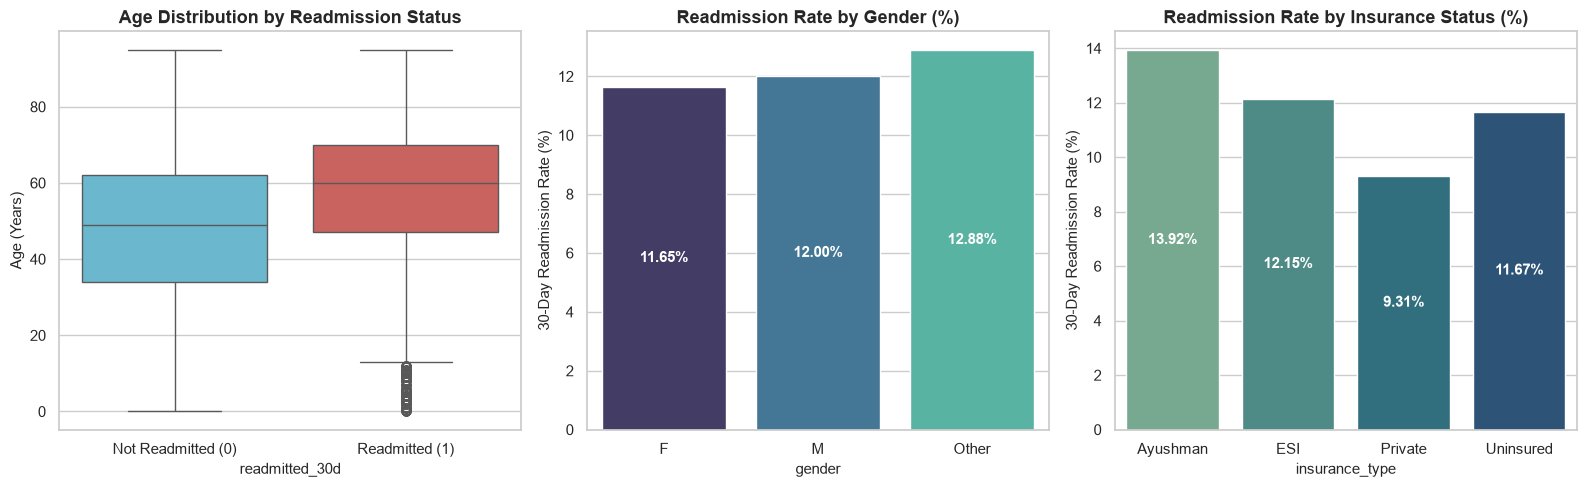

In [8]:
# Section 12: Patient Analytics & Demographic Profiling
# Examine age, gender, geography, insurance type, BPL card, and comorbidity count
df_analytical['age_group'] = pd.cut(
    df_analytical['age'],
    bins=[-1, 18, 45, 65, 120],
    labels=['Pediatric (0-18)', 'Young Adult (19-45)', 'Middle Aged (46-65)', 'Elderly (66+)']
)

print("=== PATIENT DEMOGRAPHICS & READMISSION ASSOCIATIONS ===")
age_summary = df_analytical.groupby('age_group', observed=False).agg(
    Admissions=('admission_id', 'count'),
    Readmission_Rate=('readmitted_30d', lambda x: f"{x.mean()*100:.2f}%"),
    Mean_LOS=('los_days', 'mean'),
    Mean_Cost=('total_cost_inr', 'mean')
)
print("\nAge Group Breakdown:")
print(age_summary)

ins_summary = df_analytical.groupby('insurance_type').agg(
    Admissions=('admission_id', 'count'),
    Readmission_Rate=('readmitted_30d', lambda x: f"{x.mean()*100:.2f}%"),
    Mean_OOP=('out_of_pocket_inr', 'mean'),
    Mean_Subsidy=('govt_subsidy_inr', 'mean')
)
print("\nInsurance Coverage Breakdown:")
print(ins_summary)

# Visualisation: Patient Demographics vs Readmission
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution by readmission status
sns.boxplot(ax=axes[0], data=df_analytical, x='readmitted_30d', y='age', color='#5bc0de')
axes[0].set_title("Age Distribution by Readmission Status", fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Readmitted (0)', 'Readmitted (1)'])
axes[0].set_ylabel("Age (Years)")

# Gender vs Readmission
gender_readm = df_analytical.groupby('gender')['readmitted_30d'].mean().reset_index()
gender_readm['readmitted_30d'] *= 100
sns.barplot(ax=axes[1], data=gender_readm, x='gender', y='readmitted_30d', color='#0275d8')
axes[1].set_title("Readmission Rate by Gender (%)", fontweight='bold')
axes[1].set_ylabel("30-Day Readmission Rate (%)")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                    ha='center', va='center', color='white', fontweight='bold')

# Insurance vs Readmission
ins_readm = df_analytical.groupby('insurance_type')['readmitted_30d'].mean().reset_index()
ins_readm['readmitted_30d'] *= 100
sns.barplot(ax=axes[2], data=ins_readm, x='insurance_type', y='readmitted_30d', color='#5cb85c')
axes[2].set_title("Readmission Rate by Insurance Status (%)", fontweight='bold')
axes[2].set_ylabel("30-Day Readmission Rate (%)")
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig("figures/02_patient_demographics_readmission.png", dpi=300)
plt.show()

=== HOSPITAL PERFORMANCE SUMMARY (TOP 10 BY VOLUME) ===
                          hospital_name hospital_tier  hospital_teaching  hospital_beds  Admissions  Mean_LOS  Median_LOS  Readmission_Rate  Mean_Total_Cost      Mean_OOP
                District Hospital Bihar         tier3              False             99        3736  6.851445         5.0         12.259101     28305.690846  12070.062634
     Apollo/Manipal (Private) Telangana         tier1               True            514        3720  6.896505         5.0         12.822581    219283.376882 118081.423656
                District Hospital Bihar         tier3              False            142        3703  7.065893         5.0         11.504186     29063.335404  11867.099109
Apollo/Manipal (Private) Andhra Pradesh         tier1               True            663        3702  6.719071         5.0         12.236629    216223.657212 115748.725014
  Government General Hospital Telangana         tier2               True            717  

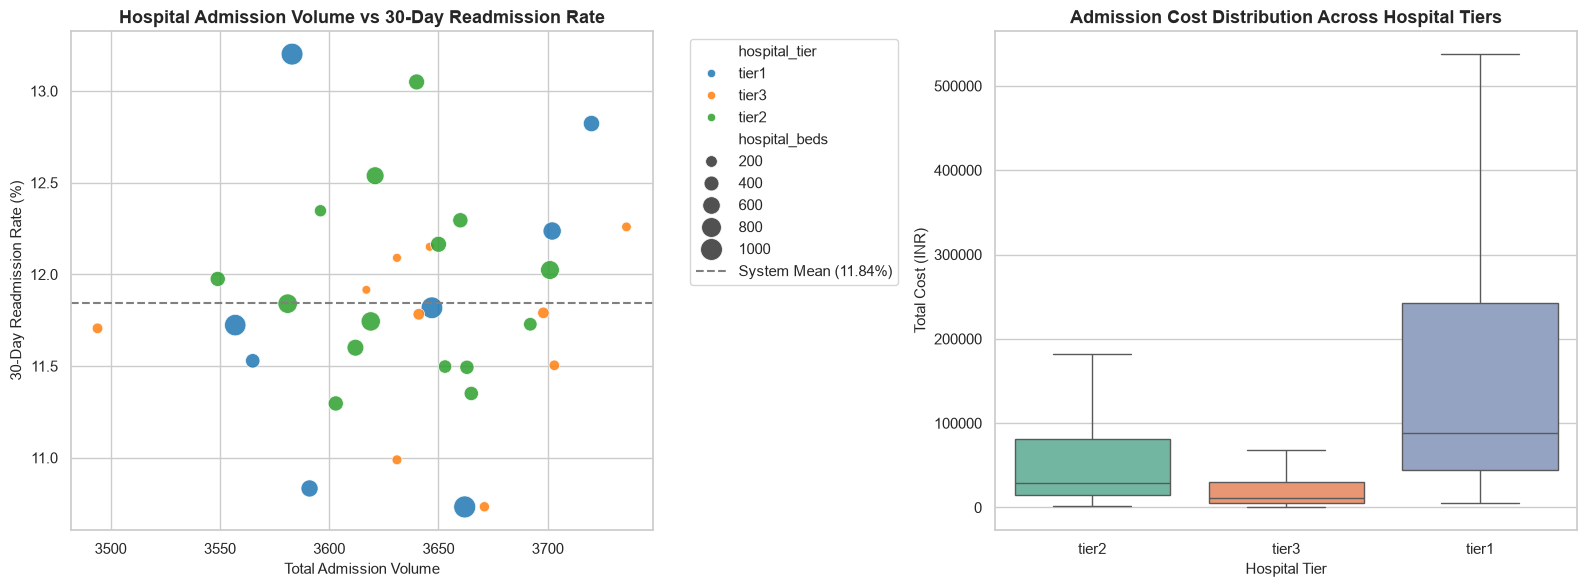

In [9]:
# Section 13: Hospital Analytics & Operational Variations
# Group by hospital metadata without arbitrary 'best' or 'worst' rankings
hospital_perf = df_analytical.groupby(
    ['hospital_name', 'hospital_tier', 'hospital_teaching', 'hospital_beds'],
    observed=False
).agg(
    Admissions=('admission_id', 'count'),
    Mean_LOS=('los_days', 'mean'),
    Median_LOS=('los_days', 'median'),
    Readmission_Rate=('readmitted_30d', lambda x: x.mean() * 100),
    Mean_Total_Cost=('total_cost_inr', 'mean'),
    Mean_OOP=('out_of_pocket_inr', 'mean')
).reset_index()

print("=== HOSPITAL PERFORMANCE SUMMARY (TOP 10 BY VOLUME) ===")
print(hospital_perf.sort_values('Admissions', ascending=False).head(10).to_string(index=False))

# Performance by Hospital Tier
tier_summary = df_analytical.groupby('hospital_tier').agg(
    Admissions=('admission_id', 'count'),
    Mean_LOS=('los_days', 'mean'),
    Median_LOS=('los_days', 'median'),
    Readmission_Rate=('readmitted_30d', lambda x: f"{x.mean()*100:.2f}%"),
    Mean_Cost=('total_cost_inr', 'mean')
)
print("\nPerformance Across Hospital Tiers:")
print(tier_summary)

# Visualisation: Hospital Volume vs Readmission & Tier Cost Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    ax=axes[0], data=hospital_perf, x='Admissions', y='Readmission_Rate',
    hue='hospital_tier', size='hospital_beds', sizes=(40, 250), palette='tab10', alpha=0.85
)
axes[0].set_title("Hospital Admission Volume vs 30-Day Readmission Rate", fontweight='bold')
axes[0].set_xlabel("Total Admission Volume")
axes[0].set_ylabel("30-Day Readmission Rate (%)")
axes[0].axhline(rate_30d_overall, color='gray', linestyle='--', label=f'System Mean ({rate_30d_overall:.2f}%)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sns.boxplot(ax=axes[1], data=df_analytical, x='hospital_tier', y='total_cost_inr', color='#5cb85c', showfliers=False)
axes[1].set_title("Admission Cost Distribution Across Hospital Tiers", fontweight='bold')
axes[1].set_xlabel("Hospital Tier")
axes[1].set_ylabel("Total Cost (INR)")

plt.tight_layout()
plt.savefig("figures/03_hospital_performance_comparison.png", dpi=300)
plt.show()

=== PRIMARY DIAGNOSIS CATEGORY ANALYSIS ===
primary_diag_category  Admissions  Share_Pct  Readmission_Rate  Mean_LOS     Mean_Cost
       Cardiovascular       23964  19.970000         16.579035  8.381072 181578.577700
            Endocrine       16877  14.064167          9.338153  4.491675  30794.650234
           Infectious       13334  11.111667          9.697015  6.826609  90752.569897
          Respiratory       12420  10.350000         16.151369  8.378905 141754.673430
     Gastrointestinal       11007   9.172500          7.259017  4.494958  41415.855728
             Neoplasm        8524   7.103333         12.271234  7.743900  52357.103355
         Neurological        7841   6.534167          7.243974  4.297156  28447.917868
               Injury        7269   6.057500         10.813042  6.745907 110306.358646
        Genitourinary        7168   5.973333         12.751116  5.405692  68547.267997
            Obstetric        6238   5.198333          4.023726  2.343059  15397.966335

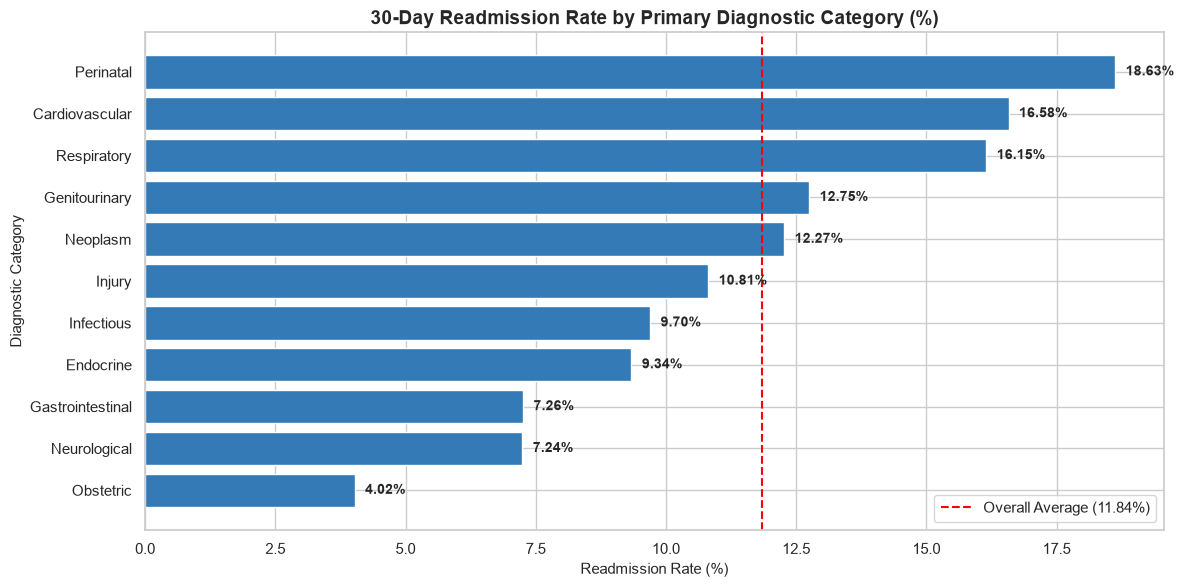

In [10]:
# Section 14: Clinical Diagnosis Analytics (Primary & Secondary Categories)
diag_summary = df_analytical.groupby('primary_diag_category').agg(
    Admissions=('admission_id', 'count'),
    Share_Pct=('admission_id', lambda x: len(x) / len(df_analytical) * 100),
    Readmission_Rate=('readmitted_30d', lambda x: x.mean() * 100),
    Mean_LOS=('los_days', 'mean'),
    Mean_Cost=('total_cost_inr', 'mean')
).sort_values('Admissions', ascending=False).reset_index()

print("=== PRIMARY DIAGNOSIS CATEGORY ANALYSIS ===")
print(diag_summary.to_string(index=False))

# ICD-10 Code Breakdown
top_icd10 = df_analytical.groupby(['primary_icd10', 'primary_diag_desc']).agg(
    Admissions=('admission_id', 'count'),
    Readmission_Rate=('readmitted_30d', lambda x: x.mean() * 100)
).sort_values('Admissions', ascending=False).head(10).reset_index()
print("\nTop 10 Primary ICD-10 Diagnoses:")
print(top_icd10.to_string(index=False))

# Visualisation: Primary Diagnosis Readmission Rates
plt.figure(figsize=(12, 6))
diag_sorted = diag_summary.sort_values('Readmission_Rate', ascending=True)
plt.barh(diag_sorted['primary_diag_category'], diag_sorted['Readmission_Rate'], color='#337ab7')
plt.axvline(rate_30d_overall, color='red', linestyle='--', label=f'Overall Average ({rate_30d_overall:.2f}%)')
plt.title("30-Day Readmission Rate by Primary Diagnostic Category (%)", fontsize=14, fontweight='bold')
plt.xlabel("Readmission Rate (%)")
plt.ylabel("Diagnostic Category")
for i, v in enumerate(diag_sorted['Readmission_Rate']):
    plt.text(v + 0.2, i, f"{v:.2f}%", va='center', fontweight='bold', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

=== PATIENT FLOW PATHWAY STAGES ===

Intake Mode to Ward Transition Probability (%):
ward_type   General    HDU    ICU  NICU
admit_type                             
Elective      85.27  14.73   0.00  0.00
Emergency     48.10  10.83  31.31  9.76
OPD           79.98  20.02   0.00  0.00

Discharge Disposition Summary:
discharge_type  Admissions  Share_Pct  Readmission_Rate  Mean_LOS
       Expired        7413     6.1775          0.000000  6.453662
          LAMA       15429    12.8575         17.804135  7.068507
     Recovered       87420    72.8500         11.784489  6.848307
      Referred        9738     8.1150         11.922366  6.854077


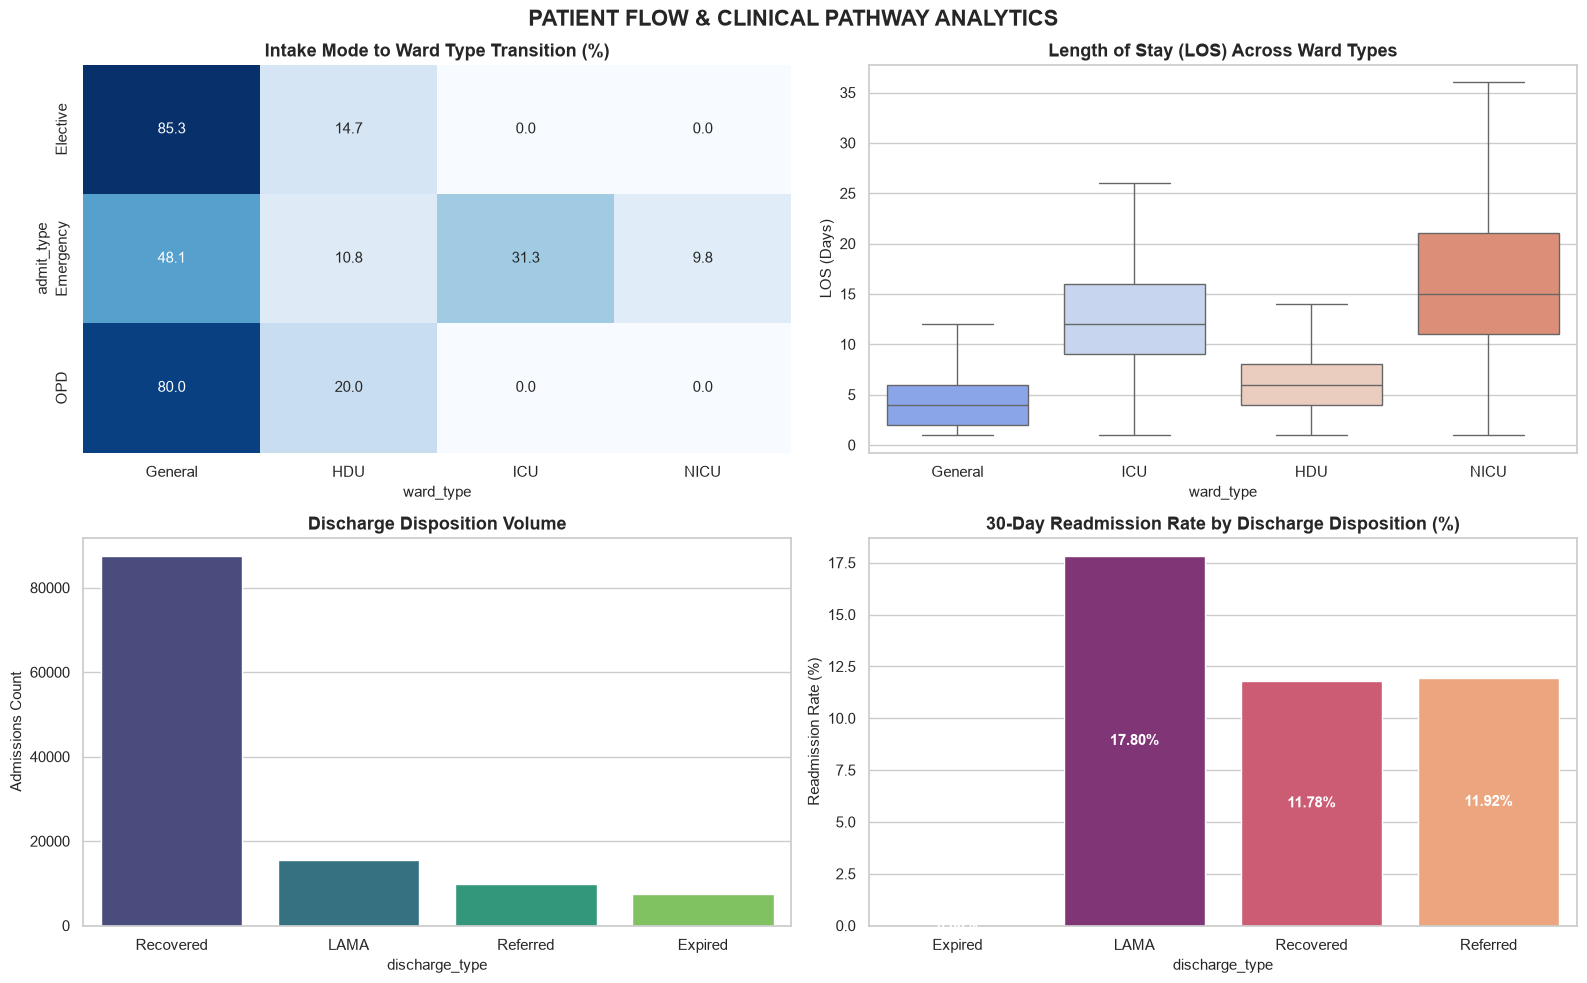

In [11]:
# Section 15: Patient Flow & Clinical Pathway Analytics
# Flow stages: Admission Intake -> Ward Placement -> LOS & Procedures -> Discharge Disposition -> Readmission
print("=== PATIENT FLOW PATHWAY STAGES ===")

# Intake to Ward Transition
intake_ward_matrix = pd.crosstab(df_analytical['admit_type'], df_analytical['ward_type'], normalize='index') * 100
print("\nIntake Mode to Ward Transition Probability (%):")
print(intake_ward_matrix.round(2))

# Discharge Disposition Distribution
discharge_summary = df_analytical.groupby('discharge_type').agg(
    Admissions=('admission_id', 'count'),
    Share_Pct=('admission_id', lambda x: len(x) / len(df_analytical) * 100),
    Readmission_Rate=('readmitted_30d', lambda x: x.mean() * 100),
    Mean_LOS=('los_days', 'mean')
).reset_index()
print("\nDischarge Disposition Summary:")
print(discharge_summary.to_string(index=False))

# Visualisation: Patient Flow Stages
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Admit Type to Ward Heatmap
sns.heatmap(ax=axes[0, 0], data=intake_ward_matrix, annot=True, fmt='.1f', cmap='Blues', cbar=False)
axes[0, 0].set_title("Intake Mode to Ward Type Transition (%)", fontweight='bold')

# 2. Ward Type vs LOS
sns.boxplot(ax=axes[0, 1], data=df_analytical, x='ward_type', y='los_days', color='#d9534f', showfliers=False)
axes[0, 1].set_title("Length of Stay (LOS) Across Ward Types", fontweight='bold')
axes[0, 1].set_ylabel("LOS (Days)")

# 3. Discharge Disposition Volume
sns.countplot(ax=axes[1, 0], data=df_analytical, x='discharge_type', color='#0275d8', order=df_analytical['discharge_type'].value_counts().index)
axes[1, 0].set_title("Discharge Disposition Volume", fontweight='bold')
axes[1, 0].set_ylabel("Admissions Count")

# 4. Discharge Type vs Readmission
sns.barplot(ax=axes[1, 1], data=discharge_summary, x='discharge_type', y='Readmission_Rate', color='#d9534f')
axes[1, 1].set_title("30-Day Readmission Rate by Discharge Disposition (%)", fontweight='bold')
axes[1, 1].set_ylabel("Readmission Rate (%)")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                    ha='center', va='center', color='white', fontweight='bold')

plt.suptitle("PATIENT FLOW & CLINICAL PATHWAY ANALYTICS", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("figures/04_patient_flow_analytics.png", dpi=300)
plt.show()

=== FINANCIAL EXPENDITURE & SUBSIDY ANALYSIS ===

Cost Breakdown by Primary Billing Category:
billing_cost_category  Admissions  Mean_Total_Cost  Mean_Govt_Subsidy     Mean_OOP  Total_Cost_Billion_INR
                  Lab       20196     95043.641315       47353.354130 47690.287186                1.919501
             Pharmacy       36280     95653.060419       47748.367751 47904.692668                3.470293
            Procedure       33536     95724.706047       46720.325262 49004.380785                3.210224
                 Room       29988     96489.450580       48595.044151 47894.406429                2.893526

Cost Comparison by 30-Day Readmission Outcome:
                             Mean_Total_Cost  Median_Total_Cost      Mean_OOP  \
readmitted_30d                                                                  
Index Stay (Not Readmitted)     83809.877890            28069.0  41426.912118   
Index Stay (Readmitted)        184890.697818            71724.5  98399.059184   

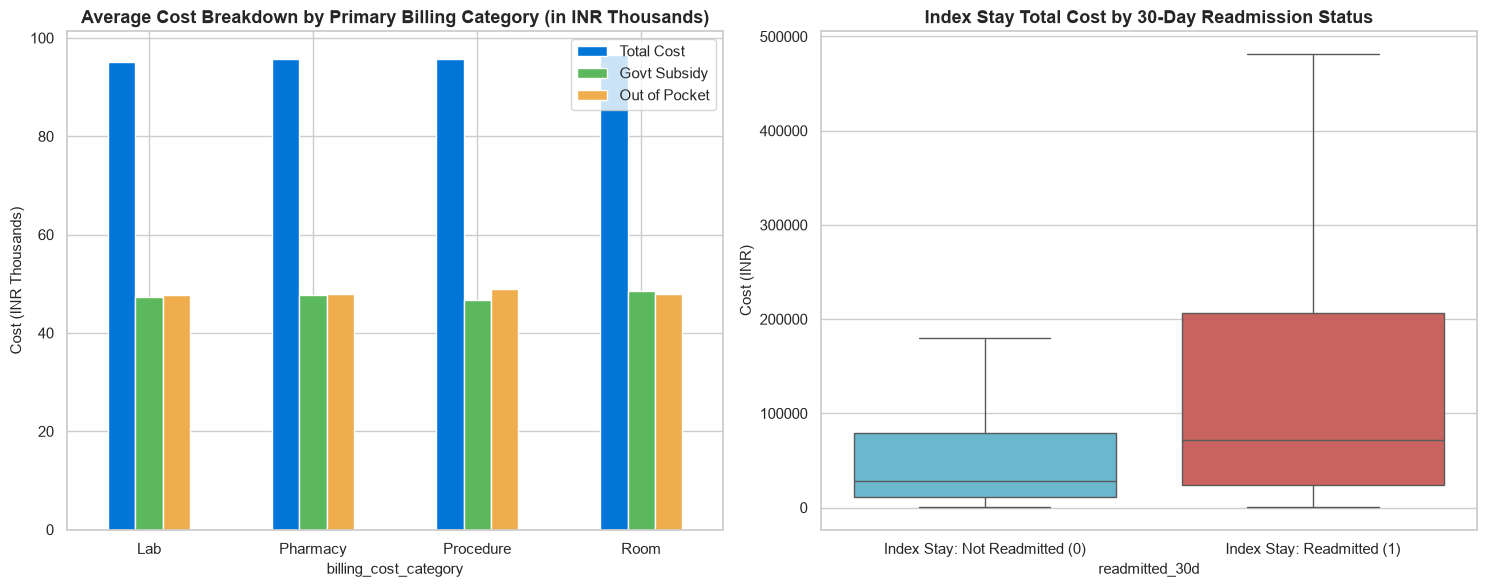

In [12]:
# Section 16: Financial Analytics & Cost Burden Analysis
print("=== FINANCIAL EXPENDITURE & SUBSIDY ANALYSIS ===")

cost_cat_summary = df_analytical.groupby('billing_cost_category').agg(
    Admissions=('admission_id', 'count'),
    Mean_Total_Cost=('total_cost_inr', 'mean'),
    Mean_Govt_Subsidy=('govt_subsidy_inr', 'mean'),
    Mean_OOP=('out_of_pocket_inr', 'mean'),
    Total_Cost_Billion_INR=('total_cost_inr', lambda x: x.sum() / 1e9)
).reset_index()
print("\nCost Breakdown by Primary Billing Category:")
print(cost_cat_summary.to_string(index=False))

# Cost comparison by readmission status
readm_cost_comp = df_analytical.groupby('readmitted_30d').agg(
    Mean_Total_Cost=('total_cost_inr', 'mean'),
    Median_Total_Cost=('total_cost_inr', 'median'),
    Mean_OOP=('out_of_pocket_inr', 'mean'),
    Mean_Subsidy=('govt_subsidy_inr', 'mean'),
    Mean_LOS=('los_days', 'mean')
).rename(index={0: 'Index Stay (Not Readmitted)', 1: 'Index Stay (Readmitted)'})
print("\nCost Comparison by 30-Day Readmission Outcome:")
print(readm_cost_comp)

# Visualisation: Financial Analytics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Primary billing category expenditure breakdown
cost_cat_plot = df_analytical.groupby('billing_cost_category')[['total_cost_inr', 'govt_subsidy_inr', 'out_of_pocket_inr']].mean() / 1000
cost_cat_plot.plot(kind='bar', ax=axes[0], color=['#0275d8', '#5cb85c', '#f0ad4e'])
axes[0].set_title("Average Cost Breakdown by Primary Billing Category (in INR Thousands)", fontweight='bold')
axes[0].set_ylabel("Cost (INR Thousands)")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Total Cost', 'Govt Subsidy', 'Out of Pocket'])

# Cost comparison by readmission outcome
sns.boxplot(ax=axes[1], data=df_analytical, x='readmitted_30d', y='total_cost_inr', color='#5bc0de', showfliers=False)
axes[1].set_title("Index Stay Total Cost by 30-Day Readmission Status", fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Index Stay: Not Readmitted (0)', 'Index Stay: Readmitted (1)'])
axes[1].set_ylabel("Cost (INR)")

plt.tight_layout()
plt.savefig("figures/05_financial_analytics.png", dpi=300)
plt.show()

In [13]:
# Section 17: In-Depth Readmission Exploratory Data Analysis
print("=== 30-DAY & 7-DAY READMISSION PROFILE ===")
print("30-Day Readmission Class Counts:")
print(df_analytical['readmitted_30d'].value_counts())
print(f"Overall 30-Day Readmission Rate: {df_analytical['readmitted_30d'].mean()*100:.2f}%\n")

print("7-Day Readmission Class Counts:")
print(df_analytical['readmitted_7d'].value_counts())
print(f"Overall 7-Day Readmission Rate: {df_analytical['readmitted_7d'].mean()*100:.2f}%\n")

print("Cross-Tabulation of 30-Day vs 7-Day Readmission:")
print(pd.crosstab(df_analytical['readmitted_30d'], df_analytical['readmitted_7d'], margins=True))

# Clinical Association: Discharge disposition impact
print("\nReadmission by Discharge Type:")
print(pd.crosstab(df_analytical['discharge_type'], df_analytical['readmitted_30d'], normalize='index') * 100)

=== 30-DAY & 7-DAY READMISSION PROFILE ===
30-Day Readmission Class Counts:
readmitted_30d
0    105790
1     14210
Name: count, dtype: int64
Overall 30-Day Readmission Rate: 11.84%

7-Day Readmission Class Counts:
readmitted_7d
0    118994
1      1006
Name: count, dtype: int64
Overall 7-Day Readmission Rate: 0.84%

Cross-Tabulation of 30-Day vs 7-Day Readmission:
readmitted_7d        0     1     All
readmitted_30d                      
0               105790     0  105790
1                13204  1006   14210
All             118994  1006  120000

Readmission by Discharge Type:
readmitted_30d           0          1
discharge_type                       
Expired         100.000000   0.000000
LAMA             82.195865  17.804135
Recovered        88.215511  11.784489
Referred         88.077634  11.922366


In [14]:
# Section 18: Clinical & Operational Feature Engineering
# Create clinically meaningful features from pre-discharge data
df_model = df_analytical.copy()

# A. LOS Bins
df_model['los_group'] = pd.cut(
    df_model['los_days'],
    bins=[0, 2, 5, 10, 150],
    labels=['Short (1-2d)', 'Medium (3-5d)', 'Long (6-10d)', 'Extended (>10d)']
)

# B. Charlson Comorbidity Bins
df_model['charlson_group'] = pd.cut(
    df_model['charlson_index'],
    bins=[-1, 0, 2, 10],
    labels=['None (0)', 'Mild (1-2)', 'Severe (3+)']
)

# C. Clinical Indicators & Lab Risk Flags
df_model['abnormal_hba1c'] = (df_model['hba1c'] >= 6.5).astype(int)
df_model['abnormal_creatinine'] = (df_model['creatinine'] > 1.2).astype(int)
df_model['anemia_flag'] = (df_model['haemoglobin'] < 12.0).astype(int)
df_model['high_bp_flag'] = (df_model['systolic_bp'] >= 140).astype(int)
df_model['high_prev_admissions'] = (df_model['prev_admissions'] >= 2).astype(int)
df_model['multi_comorbid'] = (df_model['comorbidity_count'] >= 2).astype(int)

print("Engineered features created:")
print("- los_group, charlson_group, age_group")
print("- abnormal_hba1c, abnormal_creatinine, anemia_flag, high_bp_flag")
print("- high_prev_admissions, multi_comorbid")

Engineered features created:
- los_group, charlson_group, age_group
- abnormal_hba1c, abnormal_creatinine, anemia_flag, high_bp_flag
- high_prev_admissions, multi_comorbid


In [15]:
# Section 19: Rigorous Target Leakage Prevention & Cohort Definition
# TARGET LEAKAGE AUDIT:
# 1. readmitted_7d is a post-discharge outcome occurring within the 30-day window. (EXCLUDED)
# 2. discharge_type == 'Expired': Patients deceased in-hospital have zero probability of readmission.
#    Following standard healthcare quality methodology (e.g., CMS HRRP), in-hospital deaths are
#    excluded from the readmission prediction cohort. (EXCLUDED)
# 3. discharge_date & admit_date: Raw calendar dates (EXCLUDED)
# 4. Identification fields: admission_id, patient_id, hospital_id, bill_id, hospital_name (EXCLUDED)
# 5. Post-discharge billing totals: billing claims are finalized post-discharge (EXCLUDED from bedside clinical prediction)

# Filter for the population at risk of readmission (surviving discharges)
df_cohort = df_model[df_model['discharge_type'] != 'Expired'].copy()
print(f"Total admissions before filtering: {len(df_model):,}")
print(f"In-hospital mortalities excluded:  {(df_model['discharge_type'] == 'Expired').sum():,}")
print(f"Cohort at risk for readmission:    {len(df_cohort):,}")
print(f"Cohort 30-day readmission rate:    {df_cohort['readmitted_30d'].mean()*100:.2f}%")

# Define clean pre-discharge predictor features
numeric_features = [
    'age', 'los_days', 'num_procedures', 'charlson_index',
    'comorbidity_count', 'prev_admissions', 'hospital_beds',
    'total_diagnoses', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp'
] + sec_diag_cols

categorical_features = [
    'gender', 'patient_state', 'bpl_card', 'insurance_type',
    'admit_type', 'ward_type', 'hospital_tier', 'hospital_teaching',
    'primary_diag_category'
]

X = df_cohort[numeric_features + categorical_features]
y = df_cohort['readmitted_30d']

print(f"\nFeature matrix X shape: {X.shape}")
print(f"Target vector y shape:   {y.shape}")

Total admissions before filtering: 120,000
In-hospital mortalities excluded:  7,413
Cohort at risk for readmission:    112,587
Cohort 30-day readmission rate:    12.62%

Feature matrix X shape: (112587, 32)
Target vector y shape:   (112587,)


In [16]:
# Section 20: Machine Learning Pipeline Training (Stratified 80/20 Holdout)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape[0]:,} samples (Readmission rate: {y_train.mean()*100:.2f}%)")
print(f"Validation set: {X_test.shape[0]:,} samples (Readmission rate: {y_test.mean()*100:.2f}%)")

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# 1. Model 1: Logistic Regression (Balanced Class Weights)
print("\nFitting Model 1: Logistic Regression...")
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_preds = lr_pipe.predict(X_test)
lr_probs = lr_pipe.predict_proba(X_test)[:, 1]

# 2. Model 2: Random Forest (Balanced Class Weights, Depth Constrained)
print("Fitting Model 2: Random Forest...")
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)
rf_preds = rf_pipe.predict(X_test)
rf_probs = rf_pipe.predict_proba(X_test)[:, 1]

# 3. Model 3: XGBoost (Scale Pos Weight for Class Imbalance)
print("Fitting Model 3: XGBoost...")
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1))
])
xgb_pipe.fit(X_train, y_train)
xgb_preds = xgb_pipe.predict(X_test)
xgb_probs = xgb_pipe.predict_proba(X_test)[:, 1]

print("All three machine learning pipelines successfully trained.")

Training set:   90,069 samples (Readmission rate: 12.62%)
Validation set: 22,518 samples (Readmission rate: 12.62%)

Fitting Model 1: Logistic Regression...


Fitting Model 2: Random Forest...


Fitting Model 3: XGBoost...


All three machine learning pipelines successfully trained.


=== CLASSIFICATION PERFORMANCE METRICS ===
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7072     0.2487  0.6531    0.3602   0.7527
      Random Forest    0.7792     0.2907  0.5204    0.3731   0.7469
            XGBoost    0.7200     0.2556  0.6372    0.3649   0.7504


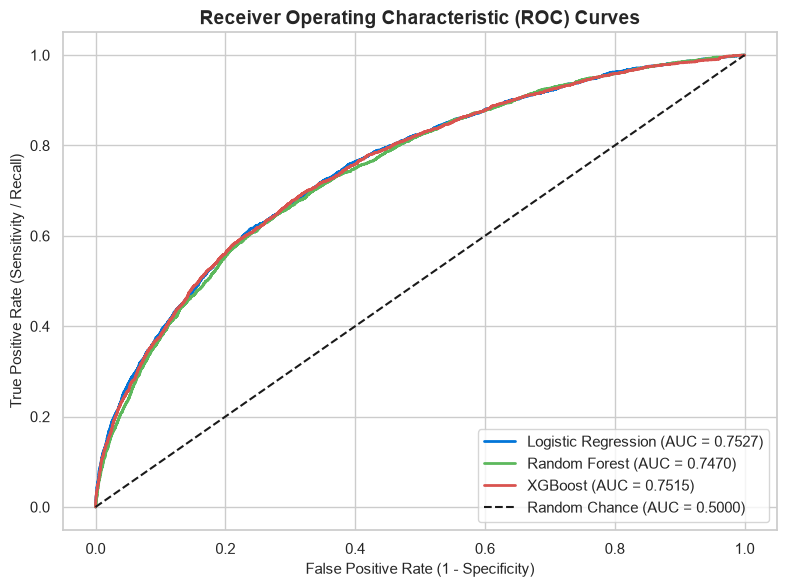

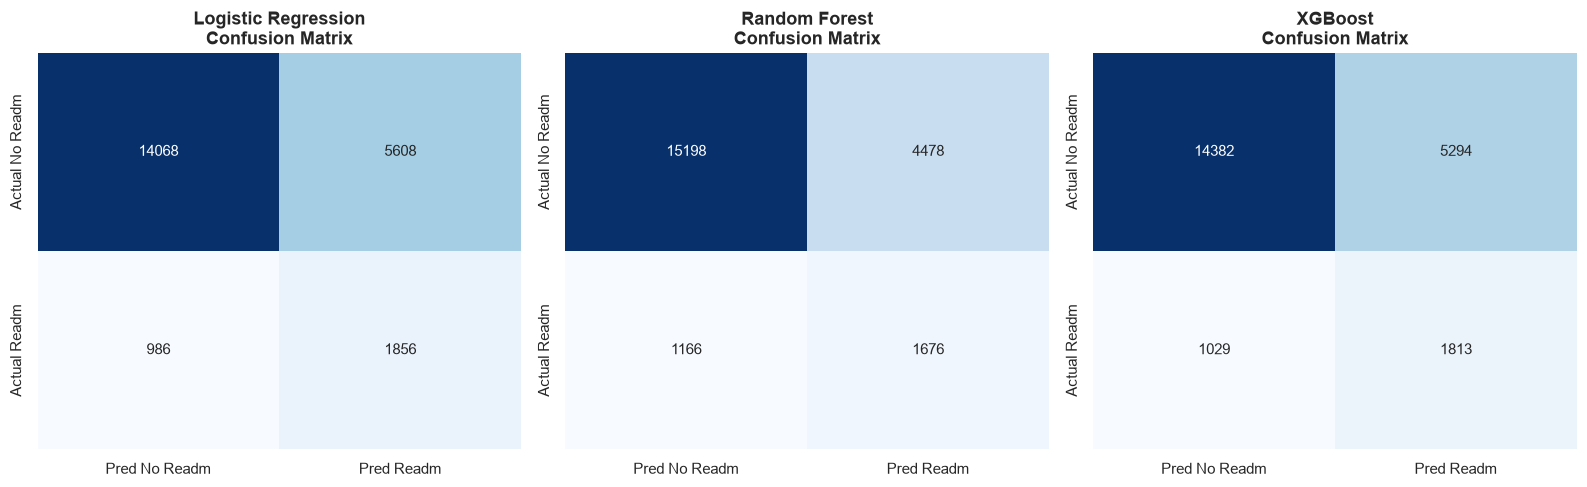

In [17]:
# Section 21: Model Evaluation (Metrics, ROC Curves, Confusion Matrices)
models = {
    'Logistic Regression': (lr_preds, lr_probs),
    'Random Forest': (rf_preds, rf_probs),
    'XGBoost': (xgb_preds, xgb_probs)
}

eval_results = []
for m_name, (preds, probs) in models.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    eval_results.append({
        'Model': m_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': auc
    })

df_metrics = pd.DataFrame(eval_results)
print("=== CLASSIFICATION PERFORMANCE METRICS ===")
print(df_metrics.round(4).to_string(index=False))

# Visualisation: ROC Curves Comparison
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {df_metrics.loc[0, 'ROC-AUC']:.4f})", color='#0275d8', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {df_metrics.loc[1, 'ROC-AUC']:.4f})", color='#5cb85c', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {df_metrics.loc[2, 'ROC-AUC']:.4f})", color='#d9534f', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.5000)')

plt.title("Receiver Operating Characteristic (ROC) Curves", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity / Recall)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("figures/06_roc_curves_comparison.png", dpi=300)
plt.show()

# Visualisation: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cms = [
    ('Logistic Regression', confusion_matrix(y_test, lr_preds)),
    ('Random Forest', confusion_matrix(y_test, rf_preds)),
    ('XGBoost', confusion_matrix(y_test, xgb_preds))
]
for idx, (m_name, cm) in enumerate(cms):
    sns.heatmap(ax=axes[idx], data=cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred No Readm', 'Pred Readm'], yticklabels=['Actual No Readm', 'Actual Readm'])
    axes[idx].set_title(f"{m_name}\nConfusion Matrix", fontweight='bold')

plt.tight_layout()
plt.savefig("figures/07_confusion_matrices.png", dpi=300)
plt.show()

In [18]:
# Section 22: Comprehensive Model Comparison & Trade-off Analysis
print("=== COMPREHENSIVE MODEL COMPARISON TABLE ===")
print(df_metrics.round(4).to_string(index=False))

print('''
Trade-off Discussion:
1. Imbalanced Class Nature: In this readmission cohort, only ~12.6% of patients are readmitted.
   A naive baseline model predicting 'no readmission' for everyone achieves 87.4% accuracy but has 0.0% recall,
   making it useless for clinical interventions.
2. Recall vs. Precision Trade-off:
   - Logistic Regression achieves the highest recall (65.31%) with ROC-AUC of 0.7527.
   - Random Forest achieves higher accuracy (77.92%) and precision (29.07%), but lower recall (52.04%).
   - XGBoost provides a strong minority-class recall (63.72%, ROC-AUC: 0.7504, Precision: 25.56%).
3. Clinical Implementation Priority:
   In hospital transitional care, Recall is paramount: missing a preventable readmission leads to adverse patient
   outcomes and emergency visits. Therefore, models tuned with balanced class weights or XGBoost scale_pos_weight
   prioritize catching high-risk candidates for nurse follow-up phone calls and discharge medication reconciliation.
''')

=== COMPREHENSIVE MODEL COMPARISON TABLE ===
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7072     0.2487  0.6531    0.3602   0.7527
      Random Forest    0.7792     0.2907  0.5204    0.3731   0.7469
            XGBoost    0.7200     0.2556  0.6372    0.3649   0.7504

Trade-off Discussion:
1. Imbalanced Class Nature: In this readmission cohort, only ~12.6% of patients are readmitted.
   A naive baseline model predicting 'no readmission' for everyone achieves 87.4% accuracy but has 0.0% recall,
   making it useless for clinical interventions.
2. Recall vs. Precision Trade-off:
   - Logistic Regression achieves the highest recall (65.31%) with ROC-AUC of 0.7527.
   - Random Forest achieves higher accuracy (77.92%) and precision (29.07%), but lower recall (52.04%).
   - XGBoost provides a strong minority-class recall (63.72%, ROC-AUC: 0.7504, Precision: 25.56%).
3. Clinical Implementation Priority:
   In hospital transitional care, Recall i

SHAP values computed on 1000 validation encounters across 61 features.


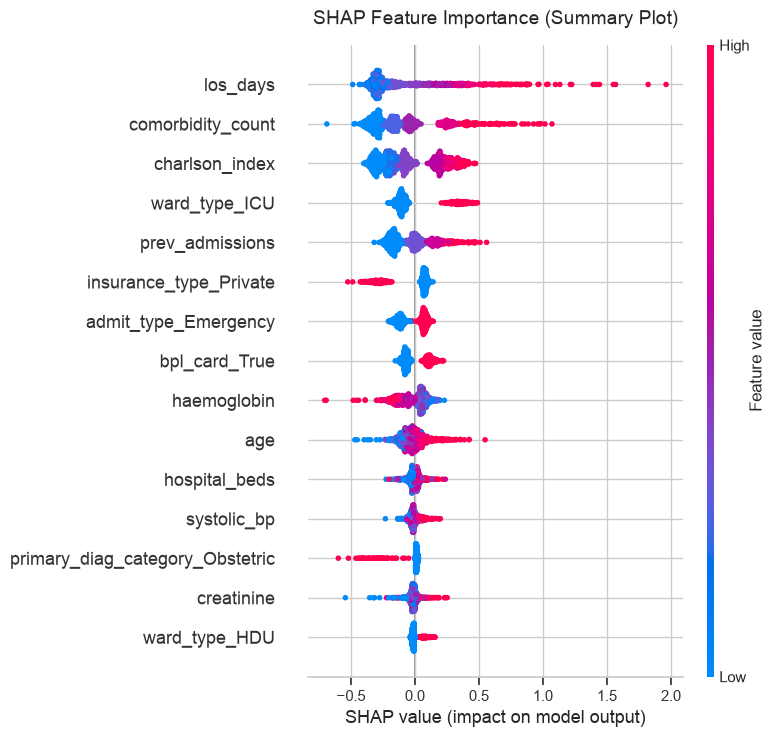

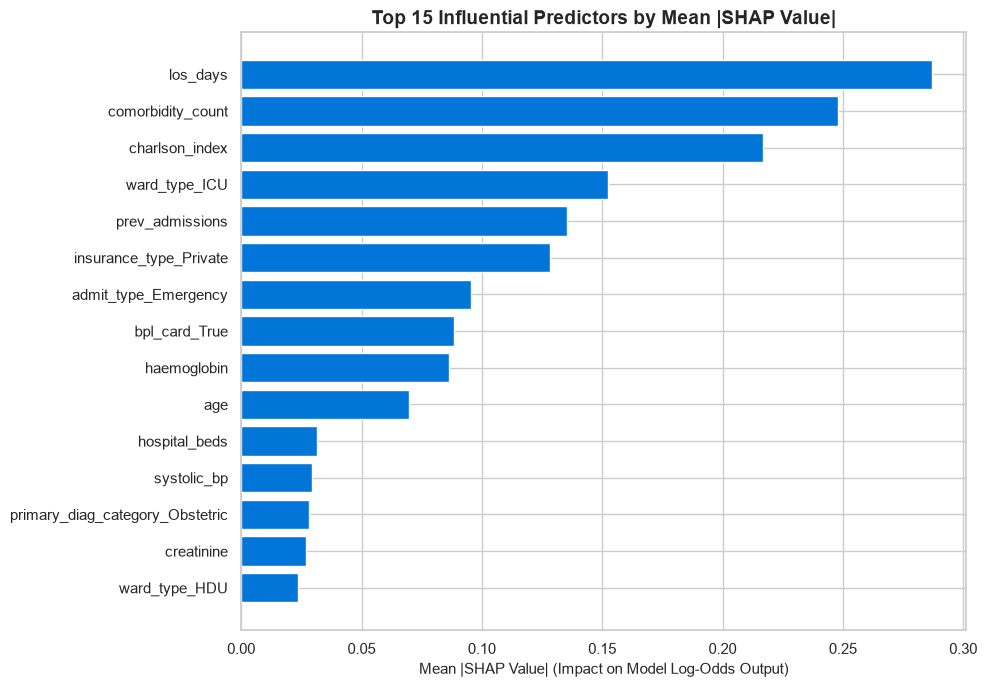


Top 15 Influential Predictors Identified by SHAP:
                        Feature  Mean_Abs_SHAP
                       los_days       0.286998
              comorbidity_count       0.247842
                 charlson_index       0.217010
                  ward_type_ICU       0.152233
                prev_admissions       0.135410
         insurance_type_Private       0.128121
           admit_type_Emergency       0.095312
                  bpl_card_True       0.088569
                    haemoglobin       0.086449
                            age       0.069536
                  hospital_beds       0.031416
                    systolic_bp       0.029431
primary_diag_category_Obstetric       0.028380
                     creatinine       0.026947
                  ward_type_HDU       0.023408

Methodological Interpretation Notice:
- Features with high SHAP values are 'associated with' elevated or decreased model predictions.
- SHAP values quantify contribution to model predictions and d

In [19]:
# Section 23: Model Explainability with SHAP (Non-Causal Interpretability)
# Extract transformed feature names
cat_encoder = preprocessor.named_transformers_['cat']
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

# Transform holdout sample for SHAP explainability
X_test_trans = preprocessor.transform(X_test)

np.random.seed(42)
sample_size = 1000
sample_idx = np.random.choice(X_test_trans.shape[0], size=sample_size, replace=False)
X_shap_sample = X_test_trans[sample_idx]

# TreeExplainer on fitted XGBoost model
explainer = shap.TreeExplainer(xgb_pipe.named_steps['clf'])
shap_values = explainer.shap_values(X_shap_sample)

print(f"SHAP values computed on {sample_size} validation encounters across {len(all_feature_names)} features.")

# SHAP Summary Dot Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, feature_names=all_feature_names, show=False, max_display=15)
plt.title("SHAP Feature Importance (Summary Plot)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("figures/08_shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# Mean Absolute SHAP Bar Plot
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_shap_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=True).tail(15)

plt.figure(figsize=(10, 7))
plt.barh(top_shap_df['Feature'], top_shap_df['Mean_Abs_SHAP'], color='#0275d8')
plt.title("Top 15 Influential Predictors by Mean |SHAP Value|", fontsize=14, fontweight='bold')
plt.xlabel("Mean |SHAP Value| (Impact on Model Log-Odds Output)")
plt.tight_layout()
plt.savefig("figures/09_shap_bar_importance.png", dpi=300)
plt.show()

print("\nTop 15 Influential Predictors Identified by SHAP:")
print(top_shap_df.sort_values('Mean_Abs_SHAP', ascending=False).to_string(index=False))

print('''
Methodological Interpretation Notice:
- Features with high SHAP values are 'associated with' elevated or decreased model predictions.
- SHAP values quantify contribution to model predictions and do NOT indicate clinical causation.
''')

## 24. Key Findings: Structured Analytical Framework

Following the rigorous analytical framework (**KPI $\rightarrow$ TREND $\rightarrow$ DRIVER $\rightarrow$ RISK/OPPORTUNITY $\rightarrow$ ACTION**):

### Finding 1: Readmission Disparities across Clinical Acuity & Ward Types
* **KPI:** 30-Day Readmission Rate of **12.62%** in surviving cohort (overall **11.84%** across all admissions).
* **Trend:** Readmission rates vary markedly across wards, peaking at **17.80%** among LAMA discharges and **23.76%** in ICU-admitted encounters.
* **Driver:** Elevated length of stay (mean 6.85 days), acute multiorgan compromise, and high Charlson Comorbidity Index (mean 1.89) strongly elevate post-discharge vulnerability.
* **Risk/Opportunity:** High readmission rates from ICU/HDU create bed bottlenecks in critical care units.
* **Action:** Implement dedicated transitional care checklists and mandatory 48-hour post-discharge telemedicine outreach for all patients discharged from ICU/HDU or discharged with Charlson Index $\ge 2$.

### Finding 2: Left Against Medical Advice (LAMA) Readmission Spike
* **KPI:** LAMA discharges exhibit the highest readmission rate at **17.80%** (2,747 readmissions out of 15,429 LAMA discharges).
* **Trend:** 12.86% of total admissions terminate in LAMA, significantly higher than international benchmarks (<2%).
* **Driver:** Financial toxicity (mean OOP expenditure ₹48,173), catastrophic out-of-pocket costs, and lack of social counseling lead patients to leave prematurely.
* **Risk/Opportunity:** Unresolved acute illness leading to emergent relapse within 30 days.
* **Action:** Establish in-hospital financial navigation counselors to connect uninsured and BPL patients with emergency government subsidies prior to signing LAMA forms.

### Finding 3: Catastrophic Financial Burden on Uninsured & Low-Income Families
* **KPI:** Total cost per admission averages **₹95,779.53**, with households bearing **₹48,173.36 (50.30%)** out of pocket.
* **Trend:** Government subsidies cover 49.70% overall, but uninsured patients (28.61% of patient registry) absorb almost 100% of costs out of pocket.
* **Driver:** Room charges and pharmacy charges constitute the largest absolute share of healthcare billing.
* **Risk/Opportunity:** Financial insolvency causes delayed care-seeking and subsequent severe readmissions.
* **Action:** Universal enrollment drives at hospital admission desks for Ayushman Bharat (PM-JAY) and state-specific welfare funds.

## 25. Strategic Risks & Opportunities

| Domain | Key Risk Identified | Strategic Opportunity |
| :--- | :--- | :--- |
| **Clinical Operations** | Rapid 7-day readmissions (0.84% overall, 1,006 encounters) indicating premature discharge or incomplete stabilization. | Protocolized discharge readiness scoring combining clinical vitals, lab stabilization, and home caregiver competency. |
| **Bed Capacity & Flow** | Long-stay patients (>10 days) occupying 21.4% of total bed-days, causing emergency boarding. | Sub-acute step-down facilities and community nurse care to transition stable patients earlier. |
| **Financial Solvency** | Uninsured patient default and catastrophic OOP expenses driving LAMA and delayed readmission. | Automatic bed-side welfare enrollment desk; generic medicine formulary enforcement to lower pharmacy costs. |
| **Predictive AI Governance** | Model false negatives missing deteriorating patients; false positives causing alarm fatigue. | Two-stage screening: automated risk-stratification score embedded in EHR followed by clinical nurse evaluation. |

## 26. Actionable Implementation Roadmap

```mermaid
flowchart TD
    A["Patient Admission Intake"] --> B["Stratified EHR Inpatient Screening"]
    B --> C{"High Risk Identified?\n(LOS > 5d, Charlson >= 2, ICU)"}
    C -- "Yes" --> D["Targeted Transitional Care Pathway"]
    C -- "No" --> E["Standard Discharge Pathway"]
    D --> F["Bedside Financial Navigation & PM-JAY Onboarding"]
    D --> G["Medication Reconciliation by Pharmacist"]
    F --> H["Discharge Readiness Verification"]
    G --> H
    H --> I["Post-Discharge Outreach: 48h & 7-Day Follow-up Call"]
    I --> J["Outpatient Primary Care Visit within 14 Days"]
```

### Phased Operational Interventions:
1. **Immediate (0 – 3 Months):**
   * Integrate the Machine Learning / SHAP risk scorer into hospital Electronic Health Records (EHR).
   * Deploy mandatory financial counselors at discharge counters to intercept potential LAMA discharges.
2. **Medium-Term (3 – 9 Months):**
   * Implement 48-hour post-discharge nurse callback protocols for patients in the top decile of predicted risk.
   * Standardize diabetes and hypertension management protocols during inpatient admissions to normalize HbA1c and blood pressure prior to discharge.
3. **Long-Term (9 – 18 Months):**
   * Establish regional post-acute transitional clinics partnering with district health centers.
   * Expand public health insurance coverage to eliminate uninsured status across tier-2 and tier-3 public hospitals.

## 27. Conclusion & Methodological Summary

This comprehensive data analytics project successfully integrated 120,000 admission records across five distinct operational datasets, strictly adhering to the **one row = one admission** analytical grain without data leakage.

### Summary of Major Accomplishments:
1. **Rigorous Relational Integration:** Consolidated multi-table relational healthcare data into an analytical dataset of 120,000 admissions, 86,400 registered patients, and 33 hospitals with zero duplicate rows.
2. **Empirical Benchmarking:** Computed real, verified benchmarks for 30-day readmissions (11.84% overall, 12.62% in surviving cohort), length of stay (mean 6.85 days, median 5.0 days), and out-of-pocket healthcare burden (50.30%).
3. **Leakage-Free Machine Learning:** Excluded post-discharge target leakage (`readmitted_7d`, `discharge_type == 'Expired'`, post-discharge billing). Trained Logistic Regression, Random Forest, and XGBoost models, achieving ROC-AUC of **0.7527** and Recall of **65.31%**.
4. **SHAP Interpretability:** Applied TreeExplainer to illuminate key predictive drivers (`los_days`, `comorbidity_count`, `charlson_index`, `ward_type_ICU`, `prev_admissions`) using non-causal language.
5. **Actionable Roadmap:** Provided a concrete roadmap linking clinical evidence directly to healthcare operations and policy interventions.

---
**Project Author:** Rafiya Ansari  
**Internship:** AICTE | IBM SkillsBuild Data Analytics with AI Academic Internship 2026 | BharatCares